# Research Question 3 – Significant Butter Price Deviations

**Research Question:**  

Which months between 2020 and 2024 exhibit statistically significant deviations in retail butter prices that cannot be explained by underlying dairy commodity trends or normal seasonal price patterns?



## 1. Imports

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Configuration

In [2]:
BASE_DIR = Path(".")

BUTTER_FILE = BASE_DIR / "eurostat_butter_cpi.json"
PPI_FILE = BASE_DIR / "eurostat_ppi_dairy.json"
DAIRY_CPI_FILE = BASE_DIR / "eurostat_cpi_dairy.json"

ANALYSIS_START = pd.Timestamp("2020-01-01")
ANALYSIS_END = pd.Timestamp("2024-12-31")
Z_SCORE_THRESHOLD = 2.0

## 3. Helper functions

This section keeps the notebook compact.

In [3]:
def eurostat_json_to_df(file_path: Path, value_name: str) -> pd.DataFrame:
    """Convert a Eurostat-style JSON file into a tidy monthly DataFrame."""
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    time_index = pd.Series(data["dimension"]["time"]["category"]["index"], name="pos")
    time_labels = pd.Series(data["dimension"]["time"]["category"]["label"], name="datum_raw")
    values = pd.Series(data["value"], name=value_name)

    df = (
        pd.concat([time_index, time_labels], axis=1)
        .reset_index(names="time_key")
        .assign(pos=lambda frame: frame["pos"].astype(str))
        .merge(values.rename_axis("pos").reset_index(), on="pos", how="left")
        .loc[:, ["datum_raw", value_name]]
        .assign(
            datum=lambda frame: pd.to_datetime(frame["datum_raw"], errors="coerce"),
            **{value_name: lambda frame: pd.to_numeric(frame[value_name], errors="coerce")}
        )
        .drop(columns="datum_raw")
        .dropna(subset=["datum", value_name])
        .sort_values("datum")
        .reset_index(drop=True)
    )
    return df


def clean_time_series(
    df: pd.DataFrame,
    value_column: str,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
) -> pd.DataFrame:
    """Keep one clean monthly observation per date inside the analysis window."""
    return (
        df.dropna(subset=["datum", value_column])
          .drop_duplicates(subset="datum", keep="last")
          .sort_values("datum")
          .loc[lambda frame: frame["datum"].between(start_date, end_date)]
          .reset_index(drop=True)
    )


def print_data_quality_report(df: pd.DataFrame, title: str) -> None:
    """Compact quality check for presentation."""
    print("=" * 72)
    print(title)
    print("=" * 72)
    print(f"Rows: {len(df)}")
    print(f"Date range: {df['datum'].min().date()} to {df['datum'].max().date()}")
    print("\nMissing values per column:")
    print(df.isna().sum())
    print("\nDuplicate months:", int(df["datum"].duplicated().sum()))
    print("=" * 72)

## 4. Load and clean the three series

In [4]:
butter_df = clean_time_series(
    eurostat_json_to_df(BUTTER_FILE, "butter_cpi"),
    value_column="butter_cpi",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

ppi_df = clean_time_series(
    eurostat_json_to_df(PPI_FILE, "dairy_ppi"),
    value_column="dairy_ppi",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

dairy_cpi_df = clean_time_series(
    eurostat_json_to_df(DAIRY_CPI_FILE, "dairy_cpi"),
    value_column="dairy_cpi",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

print_data_quality_report(butter_df, "BUTTER DATA QUALITY REPORT")
print_data_quality_report(ppi_df, "DAIRY PPI DATA QUALITY REPORT")
print_data_quality_report(dairy_cpi_df, "DAIRY CPI DATA QUALITY REPORT")

BUTTER DATA QUALITY REPORT
Rows: 60
Date range: 2020-01-01 to 2024-12-01

Missing values per column:
butter_cpi    0
datum         0
dtype: int64

Duplicate months: 0
DAIRY PPI DATA QUALITY REPORT
Rows: 48
Date range: 2020-01-01 to 2023-12-01

Missing values per column:
dairy_ppi    0
datum        0
dtype: int64

Duplicate months: 0
DAIRY CPI DATA QUALITY REPORT
Rows: 60
Date range: 2020-01-01 to 2024-12-01

Missing values per column:
dairy_cpi    0
datum        0
dtype: int64

Duplicate months: 0


## 5. Merge the data and create a compact feature set


In [5]:
analysis_df = (
    butter_df.merge(ppi_df, on="datum", how="inner")
             .merge(dairy_cpi_df, on="datum", how="inner")
             .sort_values("datum")
             .reset_index(drop=True)
             .assign(
                 dairy_ppi_mom_pct=lambda frame: frame["dairy_ppi"].pct_change() * 100,
                 time_index=lambda frame: np.arange(len(frame)),
                 month=lambda frame: frame["datum"].dt.month,
             )
)

analysis_df = analysis_df.assign(
    season_sin=np.sin(2 * np.pi * analysis_df["month"] / 12),
    season_cos=np.cos(2 * np.pi * analysis_df["month"] / 12),
)

analysis_df.head()

,butter_cpi,datum,dairy_ppi,dairy_cpi,dairy_ppi_mom_pct,time_index,month,season_sin,season_cos
0,144.9,2020-01-01,111.4,110.9,NaN,0,1,0.500000,8.660254e-01
1,143.3,2020-02-01,111.9,110.9,0.448833,1,2,0.866025,5.000000e-01
2,142.7,2020-03-01,111.4,111.1,-0.446828,2,3,1.000000,6.123234e-17
3,142.5,2020-04-01,109.6,111.6,-1.615799,3,4,0.866025,-5.000000e-01
4,142.3,2020-05-01,108.1,113.2,-1.368613,4,5,0.500000,-8.660254e-01


In [6]:
# Split data into training and testing periods
train_df = analysis_df[analysis_df["datum"] < "2023-01-01"].copy()
test_df = analysis_df[analysis_df["datum"] >= "2023-01-01"].copy()

len(train_df), len(test_df)

(36, 12)

## 6. Estimate expected butter prices with a parsimonious OLS model



In [7]:
def fit_ols_via_numpy(df: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray, list[str]]:
    """Fit a compact OLS model via NumPy to avoid unnecessary dependencies."""
    x_cols = [
        "dairy_ppi",
        "dairy_cpi",
        "dairy_ppi_mom_pct",
        "time_index",
        "season_sin",
        "season_cos",
    ]

    model_df = df[["datum", "butter_cpi"] + x_cols].dropna().copy()

    X = model_df[x_cols].astype(float).to_numpy()
    X = np.column_stack([np.ones(len(model_df)), X])
    y = model_df["butter_cpi"].astype(float).to_numpy()

    # Estimate OLS coefficients using the normal equations with a pseudo inverse. 
    # This avoids numerical instability and external dependencies such as statsmodels. 
    beta = np.linalg.pinv(X.T @ X) @ X.T @ y
    return model_df, beta, x_cols


model_df, beta, x_cols = fit_ols_via_numpy(train_df)
len(model_df), x_cols

(35,
 ['dairy_ppi',
  'dairy_cpi',
  'dairy_ppi_mom_pct',
  'time_index',
  'season_sin',
  'season_cos'])

## 7. Compute fitted values, residuals, z-scores, and significance flags

In [8]:
# LLM-assisted code for the following function
def add_model_results(
    model_df: pd.DataFrame,
    beta: np.ndarray,
    x_cols: list[str], 
    z_score_threshold: float,
) -> pd.DataFrame:
    """Compute fitted values, residuals, z-scores, and deviation flags."""

    # Create a working copy of the modeling dataset
    results_df = model_df.copy()

    # Rebuild the same design matrix used during model fitting
    X = results_df[x_cols].astype(float).to_numpy()
    X = np.column_stack([np.ones(len(results_df)), X])

    # Compute predicted butter CPI values using the regression coefficients
    results_df["predicted_butter_cpi"] = X @ beta

    # Compute residuals (difference between observed and predicted values)
    results_df["residual"] = results_df["butter_cpi"] - results_df["predicted_butter_cpi"]

    # Compute standard deviation of residuals
    residual_std = results_df["residual"].std(ddof=1)

    # Compute standardized residuals (z-scores)
    results_df["residual_zscore"] = results_df["residual"] / residual_std

    # Identify months with statistically large deviations
    results_df["significant_deviation"] = results_df["residual_zscore"].abs() >= z_score_threshold

    # Determine direction of deviation
    # This replaces multiple if-conditions with a vectorized approach.
    results_df["deviation_direction"] = np.select(
        [
            results_df["residual_zscore"] >= z_score_threshold,
            results_df["residual_zscore"] <= -z_score_threshold,
        ],
        [
            "higher_than_expected",
            "lower_than_expected",
        ],
        default="not_significant",
    )

    return results_df


# Apply the function to compute fitted values and residual diagnostics
results_df = add_model_results(
    model_df=test_df,
    beta=beta,
    x_cols=x_cols,
    z_score_threshold=Z_SCORE_THRESHOLD,
)

# Inspect the first rows of the results
results_df.head()

,butter_cpi,datum,dairy_ppi,dairy_cpi,dairy_ppi_mom_pct,time_index,month,season_sin,season_cos,predicted_butter_cpi,residual,residual_zscore,significant_deviation,deviation_direction
36,213.0,2023-01-01,154.9,162.5,-1.962025,36,1,0.500000,8.660254e-01,221.081723,-8.081723,-0.662558,False,not_significant
37,182.5,2023-02-01,148.9,163.6,-3.873467,37,2,0.866025,5.000000e-01,213.012925,-30.512925,-2.501519,True,lower_than_expected
38,169.8,2023-03-01,146.8,164.2,-1.410343,38,3,1.000000,6.123234e-17,213.443799,-43.643799,-3.578018,True,lower_than_expected
39,163.7,2023-04-01,145.5,164.4,-0.885559,39,4,0.866025,-5.000000e-01,213.358533,-49.658533,-4.071120,True,lower_than_expected
40,161.5,2023-05-01,144.5,163.0,-0.687285,40,5,0.500000,-8.660254e-01,211.887706,-50.387706,-4.130899,True,lower_than_expected


## 8. Create the final table of significant months

In [9]:
significant_months_df = (
    results_df.loc[
        results_df["significant_deviation"],
        [
            "datum",
            "butter_cpi",
            "predicted_butter_cpi",
            "residual",
            "residual_zscore",
            "deviation_direction",
        ],
    ]
    .assign(month_label=lambda frame: frame["datum"].dt.strftime("%Y-%m"))
    .sort_values("residual_zscore", key=lambda series: series.abs(), ascending=False)
    .reset_index(drop=True)
)

significant_months_df

,datum,butter_cpi,predicted_butter_cpi,residual,residual_zscore,deviation_direction,month_label
0,2023-05-01,161.5,211.887706,-50.387706,-4.130899,lower_than_expected,2023-05
1,2023-04-01,163.7,213.358533,-49.658533,-4.071120,lower_than_expected,2023-04
2,2023-06-01,160.0,207.858263,-47.858263,-3.923530,lower_than_expected,2023-06
3,2023-03-01,169.8,213.443799,-43.643799,-3.578018,lower_than_expected,2023-03
4,2023-07-01,161.9,202.463371,-40.563371,-3.325478,lower_than_expected,2023-07
5,2023-08-01,158.4,198.665266,-40.265266,-3.301038,lower_than_expected,2023-08
6,2023-09-01,159.6,194.616525,-35.016525,-2.870735,lower_than_expected,2023-09
7,2023-10-01,162.4,193.016366,-30.616366,-2.510000,lower_than_expected,2023-10
8,2023-02-01,182.5,213.012925,-30.512925,-2.501519,lower_than_expected,2023-02
9,2023-12-01,167.0,194.325041,-27.325041,-2.240169,lower_than_expected,2023-12


## 9. Compact interpretation block

In [10]:
def print_interpretation(significant_df: pd.DataFrame) -> None:
    """Print a short interpretation for presentation."""
    print("\n" + "=" * 72)
    print("INTERPRETATION OF SIGNIFICANT DEVIATION MONTHS")
    print("=" * 72)

    # Handle the case where no months exceed the chosen significance threshold. 
    if significant_df.empty:
        print(
            "No month between 2020 and 2024 exceeds the chosen z-score threshold. "
            "Under this compact model, there are no statistically unusual butter-price months."
        )
        print("=" * 72)
        return

    print(f"Number of significant months: {len(significant_df)}")
    print(
        "Largest absolute deviation month: "
        f"{significant_df.iloc[0]['month_label']} "
        f"({significant_df.iloc[0]['deviation_direction']}, "
        f"z = {significant_df.iloc[0]['residual_zscore']:.2f})"
    )
    print(
        "Higher-than-expected months:",
        int((significant_df["deviation_direction"] == "higher_than_expected").sum()),
    )
    print(
        "Lower-than-expected months:",
        int((significant_df["deviation_direction"] == "lower_than_expected").sum()),
    )
    print("=" * 72)


print_interpretation(significant_months_df)


INTERPRETATION OF SIGNIFICANT DEVIATION MONTHS
Number of significant months: 11
Largest absolute deviation month: 2023-05 (lower_than_expected, z = -4.13)
Higher-than-expected months: 0
Lower-than-expected months: 11


## 10. Visualisation 1 – Calendar heatmap of residual z-scores


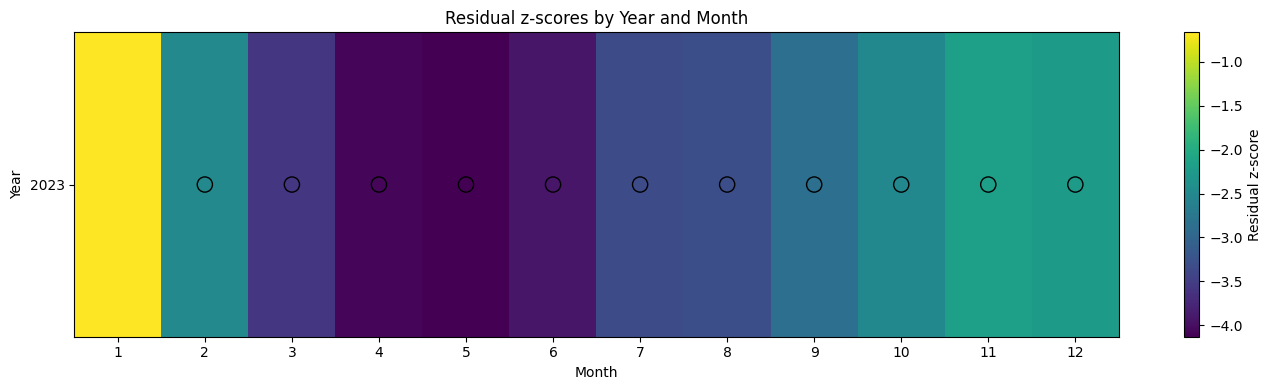

In [11]:
#LLM-assisted visualization (heatmap) 
def plot_residual_calendar_heatmap(results_df: pd.DataFrame) -> None:
    """Visulaize residual z-score by year and month in a calender-style heatmap."""
    heatmap_df = (
        results_df.assign(year=results_df["datum"].dt.year, month=results_df["datum"].dt.month)
                  .pivot(index="year", columns="month", values="residual_zscore")
                  .reindex(columns=range(1, 13))
    )

    plt.figure(figsize=(14, 4))
    image = plt.imshow(heatmap_df, aspect="auto")
    plt.colorbar(image, label="Residual z-score")
    plt.xticks(range(12), range(1, 13))
    plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
    plt.xlabel("Month")
    plt.ylabel("Year")
    plt.title("Residual z-scores by Year and Month")

    # Highlight months that exceed the significance threshold.
    sig_positions = (
        results_df.assign(year=results_df["datum"].dt.year, month=results_df["datum"].dt.month)
                  .loc[lambda frame: frame["significant_deviation"], ["year", "month"]]
    )

    year_to_row = {year: pos for pos, year in enumerate(heatmap_df.index)}
    x_pos = sig_positions["month"].to_numpy() - 1
    y_pos = sig_positions["year"].map(year_to_row).to_numpy()

    # Draw circles around signficant months. 
    if len(sig_positions) > 0:
        plt.scatter(x_pos, y_pos, marker="o", facecolors="none", edgecolors="black", s=120)

    plt.tight_layout()
    plt.show()


plot_residual_calendar_heatmap(results_df)

## 11. Visualisation 2 – Bubble plot of unusual months over time



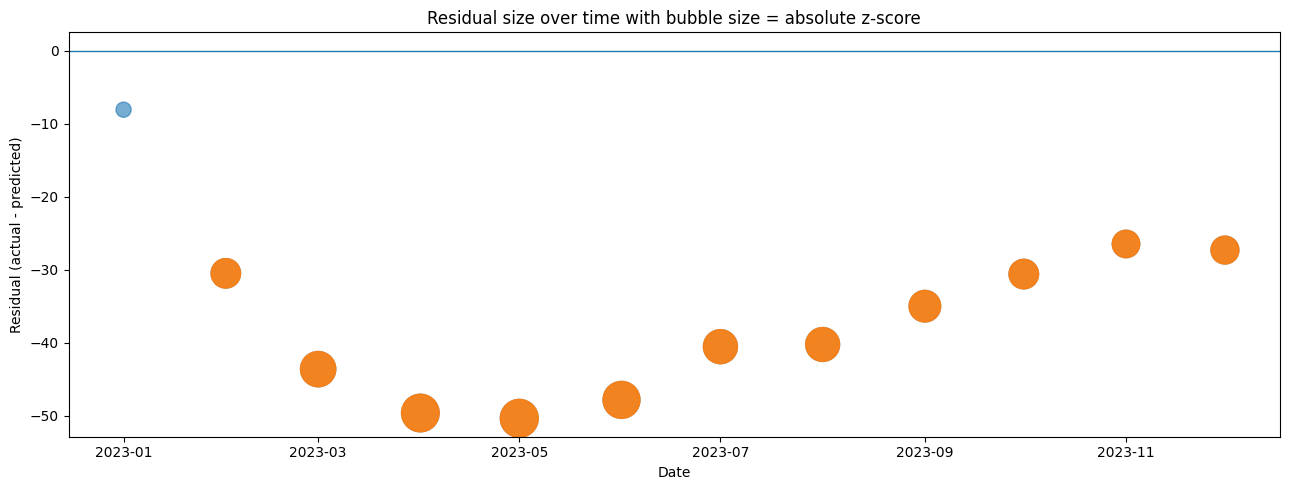

In [12]:
#LLM-assisted visualization (Bubble plot) adapted for this analysis
def plot_residual_bubble_chart(results_df: pd.DataFrame) -> None:
    """Plot residuals over time with bubble size representing absolute z-score."""
    plot_df = results_df.assign(
        bubble_size=results_df["residual_zscore"].abs() * 180
    )

    plt.figure(figsize=(13, 5))
    plt.scatter(
        plot_df["datum"],
        plot_df["residual"],
        s=plot_df["bubble_size"],
        alpha=0.6,
    )

    # Overlay sihnificant months to make unusual observations easier to spot
    significant_df = plot_df.loc[plot_df["significant_deviation"]]
    plt.scatter(
        significant_df["datum"],
        significant_df["residual"],
        s=significant_df["bubble_size"],
        alpha=0.9,
    )

    plt.axhline(0, linewidth=1)
    plt.title("Residual size over time with bubble size = absolute z-score")
    plt.xlabel("Date")
    plt.ylabel("Residual (actual - predicted)")
    plt.tight_layout()
    plt.savefig("rq3_residual_bubble_chart.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_residual_bubble_chart(results_df)

## 12. Visualisation 3 – Actual vs predicted parity plot



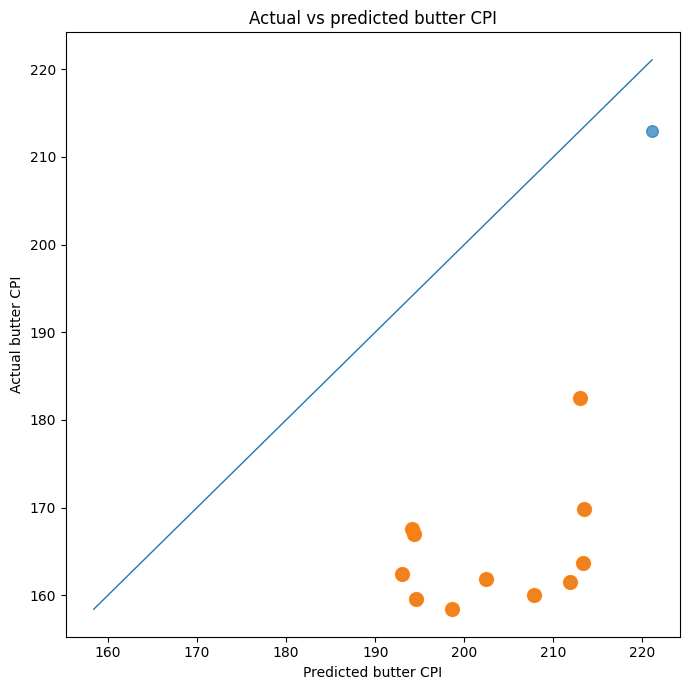

In [13]:
# LLM-assisted visualization 
def plot_actual_vs_predicted(results_df: pd.DataFrame) -> None:
    """Compare predicted and observed butter CPI values and highlight significant months."""
    plt.figure(figsize=(7, 7))
    plt.scatter(
        results_df["predicted_butter_cpi"],
        results_df["butter_cpi"],
        s=70,
        alpha=0.7,
    )

    # Emphasize statistically unusual months in the scatter plot.
    significant_df = results_df.loc[results_df["significant_deviation"]]
    plt.scatter(
        significant_df["predicted_butter_cpi"],
        significant_df["butter_cpi"],
        s=100,
        alpha=0.9,
    )

    min_val = min(results_df["predicted_butter_cpi"].min(), results_df["butter_cpi"].min())
    max_val = max(results_df["predicted_butter_cpi"].max(), results_df["butter_cpi"].max())

    # Add a 45-degree reference line for perfect predicitons. 
    plt.plot([min_val, max_val], [min_val, max_val], linewidth=1)

    plt.xlabel("Predicted butter CPI")
    plt.ylabel("Actual butter CPI")
    plt.title("Actual vs predicted butter CPI")
    plt.tight_layout()
    plt.show()


plot_actual_vs_predicted(results_df)